In [ ]:
import numpy as np # generic math functions
from scipy.optimize import curve_fit, minimize
import matplotlib.pyplot as plt # plotting library
from typing import Sequence


from qiskit import QuantumCircuit, transpile

from qiskit_aer import AerSimulator
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import efficient_su2, StatePreparation, EvolvedOperatorAnsatz, hamiltonian_variational_ansatz
#from qiskit_algorithms import VQE, VQEResult
#from qiskit_algorithms.minimum_eigensolvers import AdaptVQE, VQE
#from qiskit_algorithms.optimizers import COBYLA

### Pick constants and parameters here:

In [ ]:
N = 4 # number of qubits
J = 1.0 # interaction strength
PBC = True # set to false for open boundary conditions
gs = np.linspace(-2.5, 2.5, 11) #values of g to iterate over

In [189]:
def H_tfi(N, g=np.sqrt(2), J=1.0, PBC=False):

    h_field = [("X", [n], -g) for n in range(N)]
    if PBC:
        J_zz = [("ZZ", [n, (((n+1) % N) % N) % N], -J) for n in range(N)]
    else:
        J_zz = [("ZZ", [n, n+1], -J) for n in range(N-1)]
    

    operator_tuples = [*h_field, *J_zz]
    H =  SparsePauliOp.from_sparse_list(operator_tuples, num_qubits=N)
    return H.simplify()
    

In [190]:
# For real hardware:
"""
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2, Estimator
service = QiskitRuntimeService(channel="ibm_quantum")
backend = service.least_busy(operational=True, simulator=False)
estimator = Estimator(backend)
sampler = SamplerV2(backend)

"""

# For simulator
from qiskit_aer.primitives import SamplerV2, EstimatorV2
backend = AerSimulator(noise_model=None)
estimator = EstimatorV2()
sampler = SamplerV2()


In [191]:
def sigma_gates(circuit, n, m, params):
    """Apply Rxx, Ryy, then Rzz to qubits (n, m) in circuit.
    Args:
        circuit (QuantumCircuit): The quantum circuit to which the gates will be applied.
        n (int): The index of the first qubit.
        m (int): The index of the second qubit.
        params (list or array-like): A list or array of three parameters [param0, param1, param2] for the rotations about each axis.
    """
    circuit.rxx(params[0], n, m)
    circuit.ryy(params[1], n, m)
    circuit.rzz(params[2], n, m)

### Define PBC Ansatz

In [192]:
def get_PBC_symm_ansatz(N, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with periodic boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""

    theta = ParameterVector('th', 3*num_layers) # Does not depend on N
    phi = ParameterVector('phi', num_layers)

    symm_ansatz = QuantumCircuit(N)

    symm_ansatz.h([n for n in range(N)])

    for layer in range(num_layers):
        params = [theta[i + 3*layer] for i in range(3)]

        # Apply sigma gates in brick structure
        for n in range(N//2):
            sigma_gates(symm_ansatz, 2*n, 2*n+1, params)
        for n in range(1, N//2 +1):
            sigma_gates(symm_ansatz, 2*n-1, (2*n)%N, params)
        
        # The loop above only applies sigma gates between qubits 0 and N-1 if N is even.
        # To apply these gates when N is odd, manually apply a sigma gate between qubits 0 and N-1.
        if N % 2 == 1:
            sigma_gates(symm_ansatz, N-1, 0, params)
            
        # Apply RX gates
        symm_ansatz.rx(phi[layer], [n for n in range(N)])
        
    return symm_ansatz


In [ ]:
ansatz = get_PBC_symm_ansatz(N, num_layers=2)
ansatz.draw('mpl')

### Define OBC ansatz

In [193]:
def get_OBC_symm_ansatz(N, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with open boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""
    
    theta = ParameterVector('th', 3*num_layers)
    lam = ParameterVector('lam', 3*num_layers)
    phi = ParameterVector('phi', num_layers)

    symm_ansatz = QuantumCircuit(N)

    symm_ansatz.h([n for n in range(N)])
    
    for layer in range(num_layers):
        params = [theta[i + 3*layer] for i in range(3)]

        # Apply sigma gates in brick structure
        for n in range(N//2):
            sigma_gates(symm_ansatz, 2*n, 2*n+1, params)
        for n in range(1, (N-1)//2 +1):
            sigma_gates(symm_ansatz, 2*n-1, 2*n, params)
    
        symm_ansatz.barrier()
    
        params = [lam[i + 3*layer] for i in range(3)]

        for n in range(int(N//2)):
            
            if n == N-1-n:
                pass
            else:
                #sigma_gates(symm_ansatz, n, N-1-n, params)
                symm_ansatz.rzz(params[0], n, N-1-n)
                symm_ansatz.ryy(params[1], n, N-1-n)
                symm_ansatz.rxx(params[2], n, N-1-n)
                
        # Apply RX gates
        symm_ansatz.rx(phi[layer], [n for n in range(N)])

    return symm_ansatz



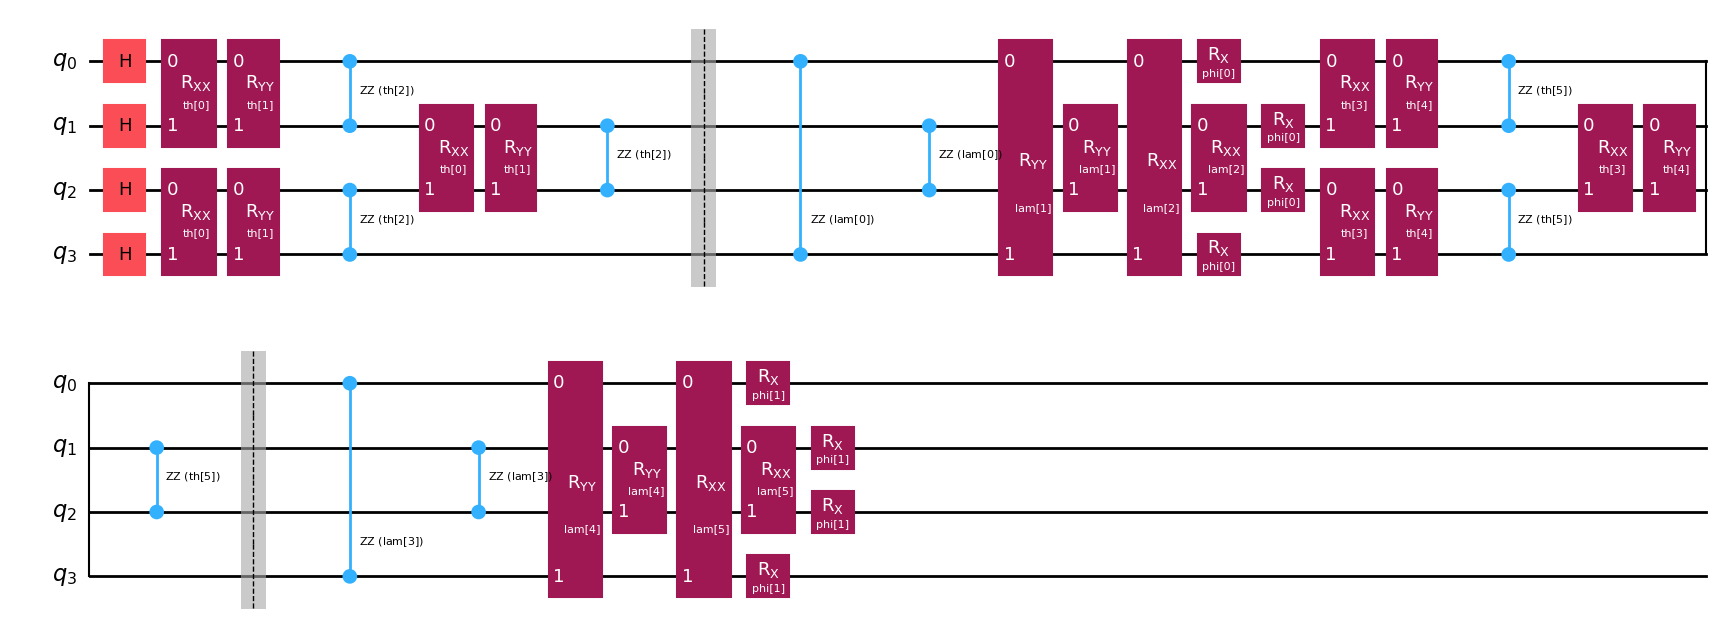

In [194]:
ansatz = get_OBC_symm_ansatz(N, num_layers=2)
ansatz.draw('mpl')

In [195]:
def cost_func(params, ansatz, hamiltonian, estimator, g):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        g (float): Transverse field strength
    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], params)
    job = estimator.run([pub], precision=1e-6)
    result = job.result()[0]
    energy = result.data.evs[0]
    
    
    cost_history_dict[str(g)]["iters"] += 1
    cost_history_dict[str(g)]["prev_vector"] = params
    cost_history_dict[str(g)]["cost_history"].append(energy)
    print(f"g={g} Iters. done: {cost_history_dict[str(g)]['iters']} [Current cost: {energy}]", 
            end="\r",
            flush=True)

    return energy

In [196]:
def get_vqe_gs(hamiltonian, ansatz, estimator, g, callback=None):

    num_params = ansatz.num_parameters
    
    x0 = 0.01 * np.random.randn(num_params)   # near zero
    estimator.options.default_shots = 5000
    options = {'maxiter': 5000, 'rhobeg': 0.1}

    res = minimize(
        cost_func,
        x0,
        args=(ansatz, hamiltonian, estimator, g),
        method="cobyla",
        options=options,
    )
    energy = res.fun
    final_params = res.x
    return energy, final_params


In [ ]:
E_GS_qiskit = []
psi_GS_qiskit = []
circuit_vqe_list = []
#Initialize cost history dictionary
outter_keys = [str(g) for g in gs]
inner_keys = ["prev_vector", "iters", "cost_history"]

cost_history_dict = {}
for outter_key in outter_keys:
    cost_history_dict[outter_key] = {}
    cost_history_dict[outter_key]["prev_vector"] = None
    cost_history_dict[outter_key]["iters"] = 0
    cost_history_dict[outter_key]["cost_history"] = []

if PBC:
    ansatz = get_PBC_symm_ansatz(N, num_layers=N//2)
else:
    ansatz = get_OBC_symm_ansatz(N, num_layers=N//2)

    
for g in gs:

    hamiltonian = H_tfi(N, J=1.0, g=g, PBC=PBC)

    """
    plus = QuantumCircuit(N)
    plus.h([n for n in range(N)])
    hva = hamiltonian_variational_ansatz(hamiltonian=hamiltonian, reps=N)
    plus_hva= plus.compose(hva)
    """
    
    E_vqe, params = get_vqe_gs(hamiltonian, ansatz, estimator, g)
    circuit_vqe = ansatz.assign_parameters(params)
    psi_vqe = Statevector(circuit_vqe)
    
    E_GS_qiskit.append(E_vqe)
    psi_GS_qiskit.append(psi_vqe)
    circuit_vqe_list.append(circuit_vqe)
    

## Compare with quspin

In [198]:
import numpy as np # generic math functions
#from scipy.optimize import curve_fit
#from scipy.special import ellipk, factorial
#from scipy.integrate import quad

import matplotlib.pyplot as plt # plotting library
#plt.rcParams["text.usetex"] = True


import time, itertools
import sys,os
os.environ['OMP_NUM_THREADS'] = '8'
os.environ['MLK_NUM_THREADS'] = '8'

from quspin.operators import hamiltonian, quantum_operator, exp_op # Hamiltonians and operators
from quspin.basis import tensor_basis, spin_basis_1d, boson_basis_1d, boson_basis_general  # Hilbert space bases
from quspin.tools.measurements import ED_state_vs_time, obs_vs_time
from quspin.tools.evolution import evolve

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projection


In [199]:
##### define model parameters #####

def H_tfi_quspin(N, J=1.0, g=0.0, PBC=False): 

    h_field=[[-g,i] for i in range(N)]
    if PBC:
        J_zz=[[-J, i, (i+1) % N] for i in range(N)]
    else:
        J_zz=[[-J, i, i+1] for i in range(N-1)] 
    static_spin =[["zz",J_zz],["x",h_field]]
    dynamic_spin=[]
    basis_spin = spin_basis_1d(L=N)
    
    H_spin=hamiltonian(static_spin, dynamic_spin, basis=basis_spin, dtype=np.complex64, check_herm=False, check_symm=False)
    return H_spin

In [275]:

E_GS_quspin = []
psi_GS_quspin = []
dense = False

for g in gs:
    H = H_tfi_quspin(N, J=1.0, g=g, PBC=PBC)
    if dense:
        E, V = H.as_dense_format().eigh()
        V = V[:, 0]
    else:
        E, V = H.eigsh(k=1, which='SA')
    E_GS_quspin.append(E[0])
    psi_GS_quspin.append(V)


In [276]:
#Fractional error
E_GS_quspin = np.array(E_GS_quspin)
error = np.abs((E_GS_quspin-E_GS_qiskit)/E_GS_quspin)

#Overlap
overlap_arr = np.zeros(len(gs))

for i in range(len(gs)):
    overlap_sqrt = np.abs(np.vdot(psi_GS_quspin[i], psi_GS_qiskit[i]))
    overlap_arr[i] = overlap_sqrt**2    

In [277]:
overlap_arr

array([0.99994855, 0.99995574, 0.99994508, 0.99940188, 0.99995389,
       0.94933371, 0.99978787, 0.99980278, 0.99995915, 0.99998753,
       0.99993278])

<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
/var/folders/26/3g2wy1kx0k72dhg7_ycw5c5c0000gr/T/ipykernel_51519/3394035671.py:24: SyntaxWarning: invalid escape sequence '\p'
  ax3.set_ylabel('$|\\langle \psi_{VQE} | \psi_{quspin} \\rangle |^2$')


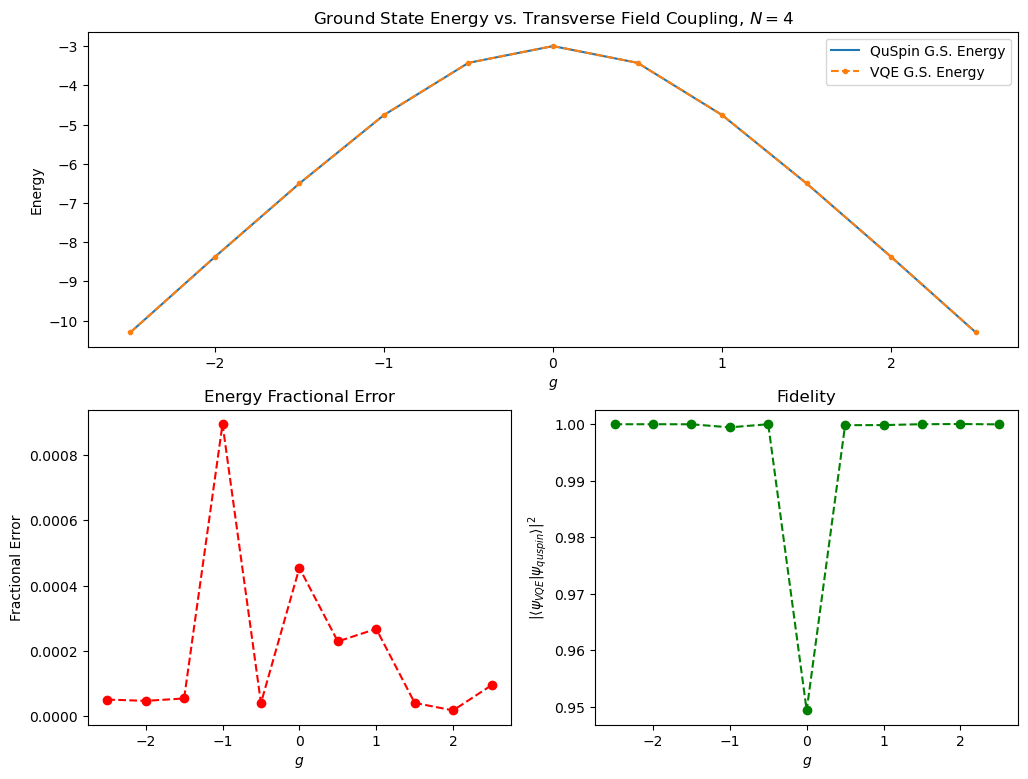

In [ ]:
layout = [['A panel', 'A panel'],
         ['B panel', 'C panel',]]
fig, axd = plt.subplot_mosaic(layout, figsize=(12, 9))
ax1 = axd['A panel']
ax1.plot(gs, E_GS_quspin, label='QuSpin G.S. Energy')
ax1.plot(gs, E_GS_qiskit, '--.', label='VQE G.S. Energy')

ax1.set_title('Ground State Energy vs. Transverse Field Coupling, $N={}$'.format(N))
ax1.set_xlabel('$g$')
ax1.set_ylabel('Energy')
ax1.legend()

ax2 = axd['B panel']
ax2.plot(gs, error, '--o', color='red')
ax2.set_title('Energy Fractional Error')
ax2.set_xlabel('$g$')
ax2.set_ylabel('Fractional Error')

ax3 = axd['C panel']
ax3.plot(gs, overlap_arr, '--o', color='green')

ax3.set_title('Fidelity')
ax3.set_xlabel('$g$')
ax3.set_ylabel('$|\\langle \psi_{VQE} | \psi_{quspin} \\rangle |^2$')

#fname = "TFI_VQE_plots_N={}_ansatz=symmOBC_layers={}".format(N, N//2)
#plt.savefig(fname + '.pdf')

#ansatz.draw('mpl').savefig(circuit_fname + '.pdf')


plt.show()